# 09 - Error Analysis and Threshold Policy

            Mục tiêu:

            - Phân tích FP/FN của final model.
            - Kiểm tra threshold policy theo năng lực review 3%, 5%, 10%.
            - Diễn giải kết quả theo nghiệp vụ.

In [1]:
from pathlib import Path
import sys
import json

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.append(str(PROJECT_ROOT))

pd.set_option("display.max_columns", 300)
pd.set_option("display.width", 200)

print("PROJECT_ROOT:", PROJECT_ROOT)

PROJECT_ROOT: e:\fraud-detection-project


In [2]:
ERROR_DIR = PROJECT_ROOT / "data" / "reports" / "final_error_analysis"
POLICY_DIR = PROJECT_ROOT / "data" / "reports" / "threshold_policy"

print("ERROR_DIR exists:", ERROR_DIR.exists())
print("POLICY_DIR exists:", POLICY_DIR.exists())

if ERROR_DIR.exists():
    print("Error files:", [p.name for p in ERROR_DIR.glob("*")])

if POLICY_DIR.exists():
    print("Policy files:", [p.name for p in POLICY_DIR.glob("*")])

ERROR_DIR exists: True
POLICY_DIR exists: True
Error files: ['error_categorical_summary.csv', 'error_numeric_summary.csv', 'error_type_counts.csv', 'false_negatives.csv', 'false_positives.csv', 'test_predictions_with_features.csv', 'true_positives.csv']
Policy files: ['threshold_policy_review_capacity.csv']


,error_type,count,ratio
0,TN,14312,0.954133
1,TP,301,0.020067
2,FP,300,0.020000
3,FN,87,0.005800


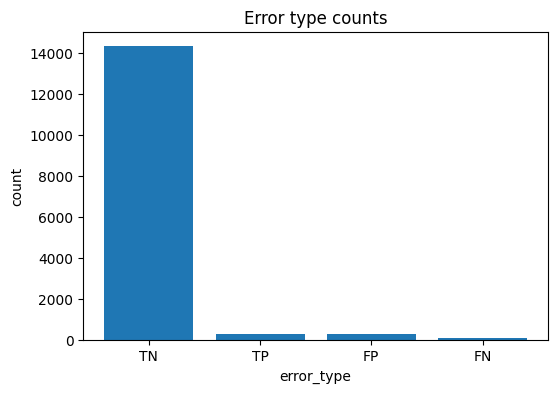

In [3]:
error_counts_path = ERROR_DIR / "error_type_counts.csv"

if error_counts_path.exists():
    error_counts = pd.read_csv(error_counts_path)
    display(error_counts)

    plt.figure(figsize=(6, 4))
    plt.bar(error_counts["error_type"], error_counts["count"])
    plt.title("Error type counts")
    plt.xlabel("error_type")
    plt.ylabel("count")
    plt.show()
else:
    print("Chưa có error_type_counts.csv. Hãy chạy scripts/12_run_error_analysis.py")

In [4]:
numeric_summary_path = ERROR_DIR / "error_numeric_summary.csv"

if numeric_summary_path.exists():
    numeric_summary = pd.read_csv(numeric_summary_path)
    display(numeric_summary)
else:
    print("Chưa có error_numeric_summary.csv")

,error_type,rows,mcc_entropy_30d_mean,mcc_entropy_30d_median,mcc_entropy_30d_p90,night_ratio_30d_mean,night_ratio_30d_median,night_ratio_30d_p90,log_amount_to_max_30d_mean,log_amount_to_max_30d_median,log_amount_to_max_30d_p90,spending_trend_mean,spending_trend_median,spending_trend_p90,distinct_countries_30d_mean,distinct_countries_30d_median,distinct_countries_30d_p90,amount_z_30d_mean,amount_z_30d_median,amount_z_30d_p90,decline_rate_30d_mean,decline_rate_30d_median,decline_rate_30d_p90,device_diversity_30d_mean,device_diversity_30d_median,device_diversity_30d_p90,credit_util_today_mean,credit_util_today_median,credit_util_today_p90,ip_score_mean,ip_score_median,ip_score_p90,txn_count_ratio_7d_30d_mean,txn_count_ratio_7d_30d_median,txn_count_ratio_7d_30d_p90
0,FN,87,1.845517,1.674,3.6292,0.444218,0.4240,0.8264,0.673249,0.525867,1.379812,2.781517,2.997,4.5730,12.390805,12.0,23.0,36263.801636,28418.105000,75619.000506,0.170080,0.153,0.3018,19.574713,19.0,35.4,0.942920,0.8850,1.7098,0.298206,0.27090,0.54284,0.275334,0.174545,0.719910
1,FP,300,0.719180,0.631,1.4964,0.234277,0.1990,0.4618,0.472225,0.447730,0.821491,1.431787,1.239,2.9046,8.770000,7.0,18.0,34746.964494,31818.065077,65918.622585,0.149683,0.138,0.2421,17.836667,17.0,34.1,0.888407,0.8725,1.6917,0.271411,0.25125,0.48218,0.285160,0.219566,0.623674
2,TN,14312,2.047897,2.050,3.6159,0.510874,0.5175,0.9060,0.794473,0.593940,1.639781,2.594288,2.611,4.5190,13.189491,13.0,23.0,33969.196736,30596.693934,67590.649507,0.168142,0.156,0.2850,20.668600,21.0,37.0,1.006399,1.0080,1.8040,0.284379,0.26490,0.50749,0.256695,0.190648,0.609756
3,TP,301,0.703837,0.563,1.5200,0.201681,0.1600,0.4440,0.440032,0.431062,0.711180,1.237478,0.998,2.6140,7.023256,6.0,14.0,42042.108085,39114.924883,80802.846154,0.137625,0.126,0.2280,16.385382,16.0,32.0,0.782850,0.6850,1.5800,0.279373,0.25900,0.49120,0.262765,0.200000,0.600000


In [5]:
categorical_summary_path = ERROR_DIR / "error_categorical_summary.csv"

if categorical_summary_path.exists():
    categorical_summary = pd.read_csv(categorical_summary_path)
    display(categorical_summary.head(80))
else:
    print("Chưa có error_categorical_summary.csv")

,error_type,feature,value,ratio,count
0,FN,payment_channel,MOBILE_APP,0.183908,16
1,FN,payment_channel,SMART_WATCH,0.172414,15
2,FN,payment_channel,IVR_PHONE,0.149425,13
3,FN,payment_channel,API_SERVER,0.149425,13
4,FN,payment_channel,WEB_BROWSER,0.137931,12
...,...,...,...,...,...
75,FP,card_entry_mode,QR_CODE,0.180000,54
76,FP,card_entry_mode,CONTACTLESS,0.160000,48
77,FP,card_entry_mode,MAGSTRIPE,0.153333,46
78,FP,card_entry_mode,CHIP,0.153333,46


In [6]:
policy_path = POLICY_DIR / "threshold_policy_review_capacity.csv"

if policy_path.exists():
    policy = pd.read_csv(policy_path)
    display(policy)

    show_cols = [
        "review_capacity",
        "selected_threshold_from_validation",
        "test_precision",
        "test_recall",
        "test_f2",
        "test_review_rate",
        "test_tp",
        "test_fp",
        "test_fn",
    ]
    show_cols = [c for c in show_cols if c in policy.columns]
    display(policy[show_cols])
else:
    print("Chưa có threshold policy. Hãy chạy scripts/13_generate_threshold_policy.py")

,review_capacity,selected_threshold_from_validation,validation_precision,validation_recall,validation_f2,validation_review_rate,test_precision,test_recall,test_f1,test_f2,test_review_rate,test_tp,test_fp,test_fn,test_tn
0,0.03,0.73,0.575058,0.658730,0.640103,0.028867,0.572597,0.721649,0.638540,0.685938,0.032600,280,209,108,14403
1,0.05,0.66,0.497196,0.703704,0.649731,0.035667,0.500832,0.775773,0.608696,0.699025,0.040067,301,300,87,14312
2,0.10,0.66,0.497196,0.703704,0.649731,0.035667,0.500832,0.775773,0.608696,0.699025,0.040067,301,300,87,14312


,review_capacity,selected_threshold_from_validation,test_precision,test_recall,test_f2,test_review_rate,test_tp,test_fp,test_fn
0,0.03,0.73,0.572597,0.721649,0.685938,0.032600,280,209,108
1,0.05,0.66,0.500832,0.775773,0.699025,0.040067,301,300,87
2,0.10,0.66,0.500832,0.775773,0.699025,0.040067,301,300,87


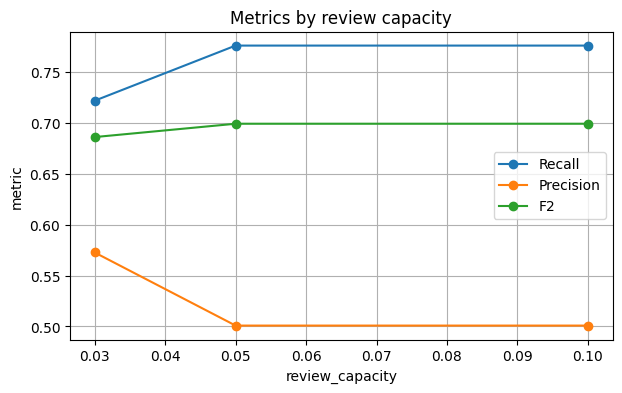

In [7]:
if policy_path.exists():
    plt.figure(figsize=(7, 4))
    plt.plot(policy["review_capacity"], policy["test_recall"], marker="o", label="Recall")
    plt.plot(policy["review_capacity"], policy["test_precision"], marker="o", label="Precision")
    plt.plot(policy["review_capacity"], policy["test_f2"], marker="o", label="F2")
    plt.title("Metrics by review capacity")
    plt.xlabel("review_capacity")
    plt.ylabel("metric")
    plt.legend()
    plt.grid(True)
    plt.show()

## Kết luận cần ghi sau khi chạy

            - FN là nhóm nguy hiểm nhất vì fraud bị bỏ sót.
            - FP gây tải review và ảnh hưởng trải nghiệm khách hàng.
            - Threshold policy giúp chọn ngưỡng theo năng lực vận hành.
            - Review capacity 5% thường là trade-off hợp lý cho bài toán này.